In [1]:
import json 
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.lines import Line2D

In [2]:
def summarize_hist(dir):
    with open(dir, 'r') as f:
        sim = json.load(f)
        
    sim = np.stack(sim)
    sim_mean = np.mean(sim, axis=0)
    
    sim_default_mean, sim_default_std = sim_mean[0], sim_mean[5]
    sim_lap_1_mean, sim_lap_1_std = sim_mean[1], sim_mean[6]
    sim_lap_2_mean, sim_lap_2_std = sim_mean[2], sim_mean[7]
    sim_iso_mean, sim_iso_std = sim_mean[3], sim_mean[8]
    sim_ep_mean, sim_ep_std = sim_mean[4], sim_mean[9]
    
    return sim_default_mean, sim_default_std, sim_lap_1_mean, sim_lap_1_std, \
            sim_lap_2_mean, sim_lap_2_std, sim_iso_mean, sim_iso_std, sim_ep_mean, sim_ep_std

In [3]:
# Load all data
data_default = summarize_hist('history/50_2_0_001_2024-08-28-02-03-57.json')

In [16]:
# Setup parameters
start_idx = 2
limit = 70
t_list = range(start_idx, limit)

plt.rcParams.update({
"text.usetex": True,
"font.family": "sans-serif",
"text.latex.preamble": r"\usepackage{amsmath}"
})

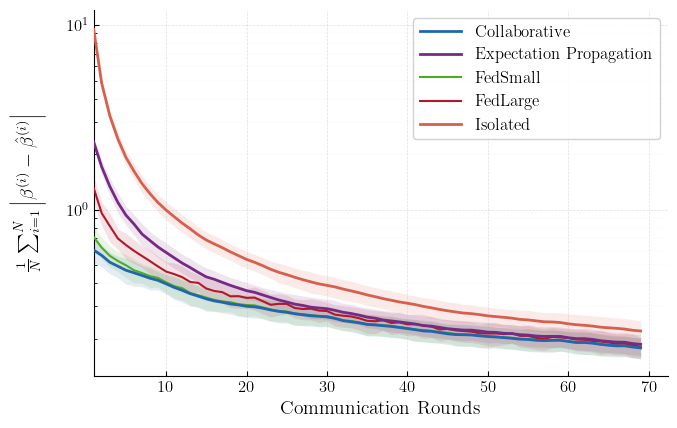

In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import time

# --- Style setup ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 15,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '0.8',
    'legend.handlelength': 2.5,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

# --- Refined muted professional palette ---
COLOR_COLLAB   = '#2166AC'   # Steel blue
COLOR_FEDSMALL = '#4DAC26'   # Muted green
COLOR_FEDLARGE = '#B2182B'   # Deep red
COLOR_ISO      = '#D6604D'   # Soft coral/orange
COLOR_EP       = '#762A83'   # Deep purple

start_idx = 1
t_list = list(range(start_idx, limit))

# --- Compute means and stds ---
lin_mean      = np.mean(data_default[0], axis=0)
lin_lap1_mean = np.mean(data_default[2], axis=0)
lin_lap2_mean = np.mean(data_default[4], axis=0)
lin_iso_mean  = np.mean(data_default[6], axis=0)
lin_ep_mean   = np.mean(data_default[8], axis=0)

lin_std       = np.std(data_default[0], axis=0)[start_idx:limit]
lin_lap1_std  = np.std(data_default[2], axis=0)[start_idx:limit]
lin_lap2_std  = np.std(data_default[4], axis=0)[start_idx:limit]
lin_iso_std   = np.std(data_default[6], axis=0)[start_idx:limit]
lin_ep_std    = np.std(data_default[8], axis=0)[start_idx:limit]

line_collab   = lin_mean[start_idx:limit]
line_fedsmall = lin_lap1_mean[start_idx:limit]
line_fedlarge = lin_lap2_mean[start_idx:limit]
line_iso      = lin_iso_mean[start_idx:limit]
line_ep       = lin_ep_mean[start_idx:limit]

# --- Figure ---
fig, ax = plt.subplots(figsize=(7, 4.5))

# Main lines
ax.plot(t_list, line_collab,   label="Collaborative",           color=COLOR_COLLAB,   lw=2.0, zorder=5)
ax.plot(t_list, line_fedsmall, label="FedSmall",                color=COLOR_FEDSMALL, lw=1.5, zorder=4)
ax.plot(t_list, line_fedlarge, label="FedLarge",                color=COLOR_FEDLARGE, lw=1.5, zorder=4)
ax.plot(t_list, line_ep,       label="Expectation Propagation", color=COLOR_EP,       lw=2.0, zorder=5)
ax.plot(t_list, line_iso,      label="Isolated",                color=COLOR_ISO,      lw=2.0, zorder=3)

# Confidence bands — no border line (lw=0)
ax.fill_between(t_list, line_collab   - lin_std,      line_collab   + lin_std,      color=COLOR_COLLAB,   alpha=0.12, linewidth=0)
ax.fill_between(t_list, line_fedsmall - lin_lap1_std, line_fedsmall + lin_lap1_std, color=COLOR_FEDSMALL, alpha=0.12, linewidth=0)
ax.fill_between(t_list, line_fedlarge - lin_lap2_std, line_fedlarge + lin_lap2_std, color=COLOR_FEDLARGE, alpha=0.12, linewidth=0)
ax.fill_between(t_list, line_ep       - lin_ep_std,   line_ep       + lin_ep_std,   color=COLOR_EP,       alpha=0.12, linewidth=0)
ax.fill_between(t_list, line_iso      - lin_iso_std,  line_iso      + lin_iso_std,  color=COLOR_ISO,      alpha=0.12, linewidth=0)

# --- Axes ---
ax.set_yscale('log')
ax.set_xlabel("Communication Rounds")

ax.set_ylabel(
    r'$\frac{1}{N} \sum_{i=1}^{N} \left| \beta^{(i)} - \hat{\beta}^{(i)} \right|$',
    rotation=90,
    labelpad=15,
    fontsize=14,
)

ax.set_xlim(left=start_idx)
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.4)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.25)

# --- Legend ordered by final performance ---
handles, labels = ax.get_legend_handles_labels()
order = [0, 3, 1, 2, 4]  # Collab, EP, FedSmall, FedLarge, Isolated
ax.legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    loc='upper right',
    frameon=True,
    ncol=1,
)

fig.tight_layout()

# --- Save ---
jour = time.strftime("%Y-%m-%d-%H-%M-%S", time.localtime())
fig.savefig(f"figure/opt_gap_{jour}.pdf", bbox_inches='tight', dpi=300)
fig.savefig(f"figure/opt_gap_{jour}.png", bbox_inches='tight', dpi=300)
plt.show()

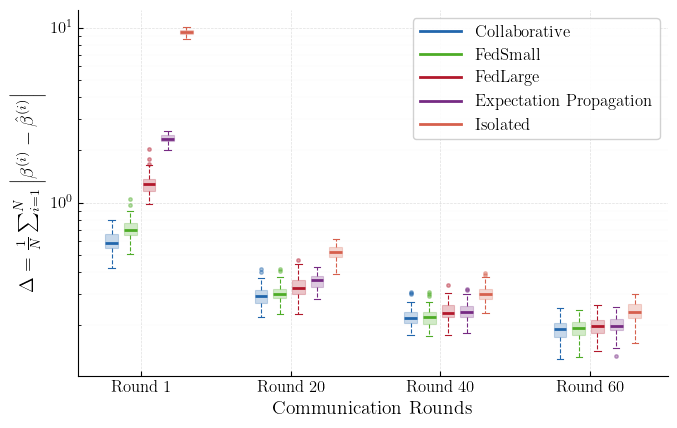

In [13]:
COLORS = [COLOR_COLLAB, COLOR_FEDSMALL, COLOR_FEDLARGE, COLOR_EP, COLOR_ISO]
legend_elem = [
    Line2D([0], [0], color=c, lw=2, label=l)
    for c, l in zip(COLORS, ["Collaborative", "FedSmall", "FedLarge", "Expectation Propagation", "Isolated"])
]
# --- Data ---
data = []
for i in range(4):
    for idx in [0, 2, 4, 8, 6]:
        data.append(data_default[idx][:, i*20 + start_idx])

# --- Positions ---
group_width, bar_width, inner_gap = 10, 2, 0.5
positions = [
    period - group_width/2 + i * (bar_width + inner_gap) + bar_width/2
    for period in [0, 20, 40, 60]
    for i in range(5)
]

# --- Figure ---
fig, ax = plt.subplots(figsize=(7, 4.5))
bp = ax.boxplot(data, positions=positions, widths=bar_width*0.85, patch_artist=True,
                medianprops=dict(linewidth=2.0),
                whiskerprops=dict(linewidth=0.8, linestyle='--'),
                capprops=dict(linewidth=0.8),
                flierprops=dict(marker='o', markersize=2.5, linestyle='none', alpha=0.4),
                boxprops=dict(linewidth=0.8))

for i, (patch, median) in enumerate(zip(bp['boxes'], bp['medians'])):
    col = COLORS[i % 5]
    patch.set(facecolor=col, edgecolor=col, alpha=0.25)
    median.set_color(col)
    for artist in [bp['whiskers'][i*2], bp['whiskers'][i*2+1],
                   bp['caps'][i*2], bp['caps'][i*2+1]]:
        artist.set_color(col)
    bp['fliers'][i].set(markerfacecolor=col, markeredgecolor=col)

# --- Axes ---
ax.set(yscale='log', xlabel="Communication Rounds",
       ylabel=r'$\Delta = \frac{1}{N} \sum_{i=1}^{N} \left| \beta^{(i)} - \hat{\beta}^{(i)} \right|$')
ax.set_xticks([0, 20, 40, 60])
ax.set_xticklabels(['Round 1', 'Round 20', 'Round 40', 'Round 60'])
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation(labelOnlyBase=False))
ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.4)
ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.25)
ax.legend(handles=legend_elem, loc='upper right', frameon=True)

fig.tight_layout()
jour = time.strftime("%Y-%m-%d-%H-%M-%S", time.localtime())
# fig.savefig(f"figure/opt_gap_var_{jour}.pdf", bbox_inches='tight', dpi=300)
# fig.savefig(f"figure/opt_gap_var_{jour}.png", bbox_inches='tight', dpi=300)
plt.show()